# NB05 — Triage policy when the queue fills with provider-blocked incidents

## 1. The question

**In a week overloaded with urgent incidents that are externally blocked (we cannot fix the
provider, only mitigate and communicate), which triage policy minimizes damage: FIFO,
severity-first, or the cμ-rule?**

This is a *prescriptive* notebook: it compares policies on a reconstructed real week plus a
simulation model. Everything below is a **one-week case study and a declared model, not a
statistically-backed general policy recommendation**, and the closing sections say exactly what
does and does not follow from it.

## 2. What ownership quietly costs when the provider is broken

The persona behind this series runs a small support/NOC team whose operation depends on
third-party cloud services. When GitHub or a CDN goes down, nobody on that team can fix it.
What the team controls is what its two on-call engineers do during the pile-up: work tickets in
arrival order, jump to the most severe one, or follow a formal priority rule.

I want this notebook to inform one concrete artifact: **the overload runbook** (the trigger
that declares "we are in overload mode", the queue discipline engineers follow once it fires,
and the explicit rule about what nobody is allowed to do). Spoiler: watch a provider's status
page. Common on-call practice has an engineer "own" an incident until it closes. For a
provider-blocked incident, that convention quietly converts engineer-hours into waiting. The
cμ-rule from queueing theory makes the cost of that convention explicit; the simulation below
puts a number on it, for one real week.

## 3. The data and its limits

`data/real/service_incidents.csv`: **787 incidents from the public status pages of 18 cloud
providers** (captured 2026-06-27, expanded 2026-07-03), 774 with a resolved duration. No row
was generated for this analysis; these are the providers' own declarations.

Limits that bind this notebook:

- **Per-provider observation windows differ wildly.** Each status-page API returns roughly its
  last ~50 incidents, which covers ≈9 days for Twilio and ≈7 years for Atlassian. Pooling
  arrival counts across providers without fixing a common window would manufacture fake "peaks"
  wherever short-window providers happen to sit. Section 4 defines the common window rule
  *before* looking for the peak week.
- **Left-censoring by declaration.** Providers publish only the incidents they chose to
  declare. The reconstructed week is the peak week of *declared* incidents.
- **`impact` is a settled snapshot, not the minute-0 declaration** (the capture is a single
  snapshot; status pages escalate impact during an incident). Here that is acceptable (we
  replay a *past* week where severities are known), but it means the replay is slightly
  optimistic about how well a real-time triager could classify arrivals.
- **Impact conventions are not comparable across providers** (Figma/Atlassian label almost
  everything `none`; Discord uses `major` liberally). The severity *weights* below are our own
  declared damage model, and the weight sensitivity check exists partly because of this.
- **Twilio caveat:** 45 incidents in 9 days (a likely platform crisis). Twilio's window is too
  short to enter the common-window panel, so the crisis does not contaminate the peak-week
  search. That is a consequence of the window rule, not a manual exclusion.
- GCP's 3 incidents have no usable timestamps and drop out; 53 rows have non-positive
  durations (3 negative, 50 zero, from timestamp glitches and instant status flips) and are
  excluded from the duration fits.
- The DORA-calibrated synthetic files are **not used** in this notebook, because no synthetic
  baseline is needed for a policy comparison on a real trace.

In [1]:
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- plot style (shared across all figures) ---
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
POLICY_COLORS = {"FIFO": "#2a78d6", "Severity-first": "#1baf7a", "cμ-rule": "#eda100"}
SEV_RAMP = {"none": "#86b6ef", "minor": "#3987e5", "major": "#1c5cab", "critical": "#0d366b"}
CRITICAL_RED = "#d03b3b"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})

df = pd.read_csv("data/real/service_incidents.csv")
for c in ["created_at", "resolved_at"]:
    df[c] = pd.to_datetime(df[c], utc=True, format="mixed")

print(f"{len(df)} incidents, {df['provider'].nunique()} providers")
print(f"rows with duration: {df['duration_min'].notna().sum()}, "
      f"non-positive durations: {(df['duration_min'] <= 0).sum()}, "
      f"rows without created_at (dropped): {df['created_at'].isna().sum()}")
df = df.dropna(subset=["created_at"])

windows = df.groupby("provider")["created_at"].agg(["min", "max", "count"])
windows["window_days"] = (windows["max"] - windows["min"]).dt.total_seconds() / 86400
print("\nPer-provider observation windows (last ~50 incidents each):")
print(windows.sort_values("window_days")[["count", "window_days"]].round(1).to_string())

787 incidents, 18 providers
rows with duration: 774, non-positive durations: 53, rows without created_at (dropped): 3

Per-provider observation windows (last ~50 incidents each):
                  count  window_days
provider                            
twilio               50          8.3
cloudflare           50         21.4
openai               25         26.4
claude_anthropic     50         30.0
github               50         64.8
zoom                 50         65.2
vercel               50         93.1
linear               25         98.2
digitalocean         50        136.6
circleci             50        211.1
datadog              50        303.4
discord              50        324.8
reddit               50        755.2
dropbox              50        775.8
figma                50        981.1
npm                  50        990.6
atlassian            34       2128.0


## 4. Method and assumptions

### 4.1 The common window and the peak week (rule declared before computing)

NB03 asks capacity questions about "the worst observed week"; this notebook reuses the same
construction and recomputes it here so the notebook is self-contained. Because observation
windows differ per provider, "the busiest week" only means something over a window during
which a **fixed panel of providers** was under observation the whole time. I fix the rule now,
before computing anything, so the peak week can't be picked to flatter any particular result:

1. Candidate common windows are intervals bounded by providers' own window edges, at least
   **28 days** long.
2. The common window is the one covered end-to-end by the **largest panel of providers**;
   ties broken by length.
3. The **peak week** is the 7-day span (day resolution, rolling) with the most incidents from
   panel providers inside the common window. Count, not severity-weighted count, is the primary
   criterion (the weighted variant is reported for honesty).

This deliberately excludes short-window providers (Twilio ≈9 days, OpenAI ≈26 days,
Cloudflare ≈21 days, Anthropic ≈30 days): a peak week must not be an artifact of when we
started observing someone.

This construction is NB05's own, and it does not land on the same window as NB03's (Section 3,
"Choosing the common window — coverage check"): the common window here runs 2026-04-28 to
2026-06-08 across an 11-provider panel, peaking 2026-05-05 to 2026-05-12 at 28 incidents, while
NB03's runs 2026-05-31 to 2026-06-27 across 9 providers, peaking 2026-06-07 to 2026-06-13 at 36.
Neither number is wrong; each notebook pre-registered its own panel-construction rule before
looking at the data, and the two rules trade off differently: NB03 anchors to the
shortest-lived provider it needs and accepts a smaller panel, NB05 maximizes panel size subject
to a 28-day floor. Read each window as its own rather than averaging them into one nobody
pre-registered.

In [2]:
edges = sorted(set(windows["min"]).union(windows["max"]))
best = None
for s in edges:
    for e in edges:
        length_days = (e - s).total_seconds() / 86400
        if length_days < 28:
            continue
        panel = tuple(p for p in windows.index
                      if windows.loc[p, "min"] <= s and windows.loc[p, "max"] >= e)
        key = (len(panel), length_days)
        if best is None or key > best[0]:
            best = (key, s, e, panel)
(panel_size, cw_days), cw_start, cw_end, panel = best
print(f"Common window: {cw_start:%Y-%m-%d %H:%M} -> {cw_end:%Y-%m-%d %H:%M} UTC "
      f"({cw_days:.1f} days)")
print(f"Panel: {panel_size} providers: {', '.join(panel)}")

cw = df[(df["provider"].isin(panel)) &
        (df["created_at"] >= cw_start) & (df["created_at"] <= cw_end)].sort_values("created_at")
print(f"Incidents from panel providers inside the common window: {len(cw)}")

daily = cw.set_index("created_at").assign(n=1)["n"].resample("D").sum()
roll7 = daily.rolling(7).sum()
week_end = roll7.idxmax() + pd.Timedelta("1D")
week_start = week_end - pd.Timedelta("7D")
week = cw[(cw["created_at"] >= week_start) & (cw["created_at"] < week_end)].copy()
week = week.sort_values("created_at").reset_index(drop=True)

print(f"\nPeak week: {week_start:%Y-%m-%d} -> {week_end:%Y-%m-%d} UTC, "
      f"{len(week)} incidents")
print("Severity mix (settled impact):", week["impact"].value_counts().to_dict())
print("Providers:", week["provider"].value_counts().to_dict())
print("Real durations in the week (min):",
      week["duration_min"].describe()[["min", "50%", "mean", "max"]].round(1).to_dict())

# weighted alternative criterion, carry-ins, simultaneity — reported for honesty
W_DEFAULT = {"none": 0.5, "minor": 1.0, "major": 3.0, "critical": 9.0}
wdaily = cw.set_index("created_at")["impact"].map(W_DEFAULT).resample("D").sum()
wk_w = wdaily.rolling(7).sum()
print(f"\nWeighted-count criterion would pick the week ending "
      f"{wk_w.idxmax() + pd.Timedelta('1D'):%Y-%m-%d} (same construction, reported only).")
carry = df[(df["provider"].isin(panel)) &
           (df["created_at"] < week_start) & (df["resolved_at"] > week_start)]
print(f"Carry-in incidents open at week start: {len(carry)}")

def max_simultaneous(frame):
    ev = []
    for _, r in frame.dropna(subset=["resolved_at"]).iterrows():
        ev += [(r["created_at"], 1), (r["resolved_at"], -1)]
    ev.sort(key=lambda t: (t[0], t[1]))
    cur = mx = 0
    for _, d in ev:
        cur += d
        mx = max(mx, cur)
    return mx

print(f"Max simultaneous open incidents (real timeline): {max_simultaneous(week)}")
print(f"Max simultaneous CRITICAL incidents: {max_simultaneous(week[week['impact']=='critical'])}")

Common window: 2026-04-28 06:08 -> 2026-06-08 19:43 UTC (41.6 days)
Panel: 11 providers: circleci, datadog, digitalocean, discord, dropbox, figma, github, linear, npm, vercel, zoom
Incidents from panel providers inside the common window: 139

Peak week: 2026-05-05 -> 2026-05-12 UTC, 28 incidents
Severity mix (settled impact): {'minor': 15, 'critical': 5, 'major': 4, 'none': 4}
Providers: {'github': 7, 'vercel': 7, 'zoom': 5, 'digitalocean': 3, 'datadog': 2, 'circleci': 2, 'discord': 2}
Real durations in the week (min): {'min': 8.4, '50%': 100.4, 'mean': 165.4, 'max': 840.7}

Weighted-count criterion would pick the week ending 2026-05-10 (same construction, reported only).
Carry-in incidents open at week start: 0
Max simultaneous open incidents (real timeline): 3
Max simultaneous CRITICAL incidents: 1


**The honest note on the real peak week.** The busiest 7 days a fixed 11-provider panel
produced in 41.6 common days is **2026-05-05 → 2026-05-12: 28 incidents (15 minor,
5 critical, 4 major, 4 none)**, led by GitHub and Vercel (7 each). The severity mix matters:
this is mostly a *minor-incident* pile-up. There were 5 criticals in the week, but **never more
than 1 critical open at a time**, and never more than 3 incidents of any severity open
simultaneously. There were no carry-in incidents open at week start. So the dramatic scenario
("4 criticals at once, 2 engineers") **did not occur in this data**. That is treated later as a
clearly-labeled hypothetical stress test, separate from the real replay. A severity-weighted
week-selection criterion would, in fact, pick a different week; I keep the pre-declared count
criterion anyway and flag the discrepancy here rather than quietly choosing after the fact.

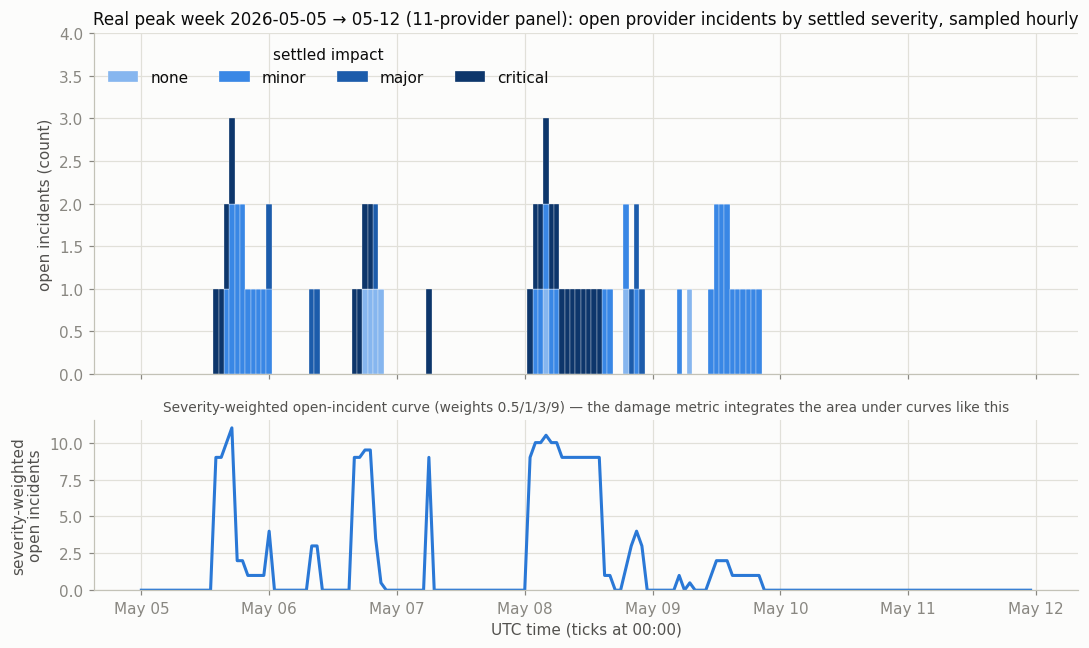

Peak simultaneous load: 3 open incidents (weighted peak 11.0)


In [3]:
# Figure 1 — hour-by-hour reconstruction of the real peak week
hours = pd.date_range(week_start, week_end, freq="h", inclusive="left")
sev_order = ["none", "minor", "major", "critical"]
open_by_sev = {s: np.zeros(len(hours)) for s in sev_order}
for _, r in week.iterrows():
    end = r["resolved_at"]
    mask = (hours >= r["created_at"]) & (hours < end)
    open_by_sev[r["impact"]][mask] += 1
weighted = sum(W_DEFAULT[s] * open_by_sev[s] for s in sev_order)

x = np.arange(len(hours))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
bottom = np.zeros(len(hours))
for s in sev_order:
    ax1.bar(x, open_by_sev[s], bottom=bottom, width=1.0, color=SEV_RAMP[s],
            edgecolor=SURFACE, linewidth=0.2, label=s)
    bottom += open_by_sev[s]
ax1.set_ylabel("open incidents (count)")
ax1.set_title("Real peak week 2026-05-05 → 05-12 (11-provider panel): "
              "open provider incidents by settled severity, sampled hourly")
ax1.legend(title="settled impact", frameon=False, ncol=4, loc="upper left")
ax1.set_ylim(0, max(bottom) + 1)

ax2.plot(x, weighted, color=POLICY_COLORS["FIFO"], linewidth=2)
ax2.set_ylabel("severity-weighted\nopen incidents")
ax2.set_ylim(0, None)
ax2.set_xlabel("UTC time (ticks at 00:00)")
ax2.set_xticks(np.arange(0, 169, 24))
ax2.set_xticklabels([(week_start + pd.Timedelta(hours=int(h))).strftime("%b %d")
                     for h in np.arange(0, 169, 24)])
ax2.set_title("Severity-weighted open-incident curve (weights 0.5/1/3/9) — "
              "the damage metric integrates the area under curves like this",
              fontsize=9, color=INK2)
fig.tight_layout()
plt.show()
print(f"Peak simultaneous load: {int(bottom.max())} open incidents "
      f"(weighted peak {weighted.max():.1f})")

### 4.2 The model: two classes of work, one damage metric, three policies

Every incident in this dataset is *externally blocked*: the provider's resolution time $R_i$
is exogenous — nothing our engineers do shortens it. What they *can* do is mitigation/
communication work $M_i$ (fail over, apply a workaround, post proactive status updates), which
reduces the damage an open incident causes while we wait. That is the formal version of
"resoluble internally vs. blocked externally": the *incident* has service rate μ ≈ 0, the
*mitigation task* has μ > 0.

I declare every parameter of the damage model here, before running any simulation, so nothing
below can be tuned to the result afterward:

- Severity weights $w$: none = 0.5, minor = 1, major = 3, critical = 9 (damage per open
  hour, in arbitrary "weighted open-incident" units). Sensitivity-checked below.
- An unmitigated open incident accrues damage at rate $w$; once the mitigation task
  completes, it accrues at **α·w with α = 0.3** until the provider resolves it.
- Mitigation effort $M_i$ ~ log-normal, with medians 20 / 30 / 60 / 90 min for
  none/minor/major/critical and σ = 0.6. This is invented (the dataset carries no
  internal-work telemetry), so I flag it as an assumption and stress-test it below (halved,
  doubled, and reordered).
- Damage metric = area under the severity-weighted open-incidents curve (the same curve in
  Figure 1's lower panel), with mitigated incidents counted at α·w. Integration runs past the
  week's end until every incident resolves, so no damage gets truncated by the calendar.

Three policies, run over 2 non-preemptive engineers:

1. **FIFO (own-until-resolved):** take incidents in arrival order; the engineer mitigates,
   then *owns the incident until the provider closes it* — the classic ticket-queue habit.
2. **Severity-first (own-until-resolved):** same ownership convention, but the queue is
   ordered by severity weight (ties by arrival): jump to the worst thing and stay with it,
   which is common on-call practice.
3. **cμ-rule:** the classic queueing result: serve the class with the highest
   damage-rate × your service rate; here priority
   $= (1-α)\,w(s)\,\mu_{mit}(s)$, with $\mu_{mit}=1/E[M]$. What the rule actually says
   about the *other* activity available per incident (passively monitoring the provider) is
   the crucial part. Monitoring has μ ≈ 0, completes nothing, and reduces no damage, so its
   cμ index is ≈ 0: the rule never staffs passive waiting. Engineers release an incident the
   moment its mitigation completes and move to the next mitigation task.

Policies 1–2 differ from policy 3 on *two* axes at once (queue ordering *and* the release
rule), and that's a real confound, not an oversight: it is how these policies are actually
practiced. To pull the axes apart, the tournament also runs a decomposition variant,
**severity-first + release**, which pairs policy 2's ordering with policy 3's release rule.

One thing worth saying plainly, since it caps how much credit any policy can take: the
provider closes incident $i$ at $a_i + R_i$ regardless of what we do, so total damage has a
large policy-independent floor. Policies only compete over how long incidents sit
*unmitigated*. How large that controllable slice actually is, is itself a result reported
below.

severity   n  log-mean  log-sd  fitted median (min)  Shapiro p on ln(dur)
    none 120      4.95    1.64                140.6                0.0031
   minor 447      4.77    1.51                118.1                0.0000
   major 122      4.37    1.06                 79.3                0.1672
critical  32      4.52    0.75                 91.5                0.1637

Durations used for fitting: 721 positive durations (pooled across providers; cross-provider DURATION pooling is allowed, unlike rate pooling).


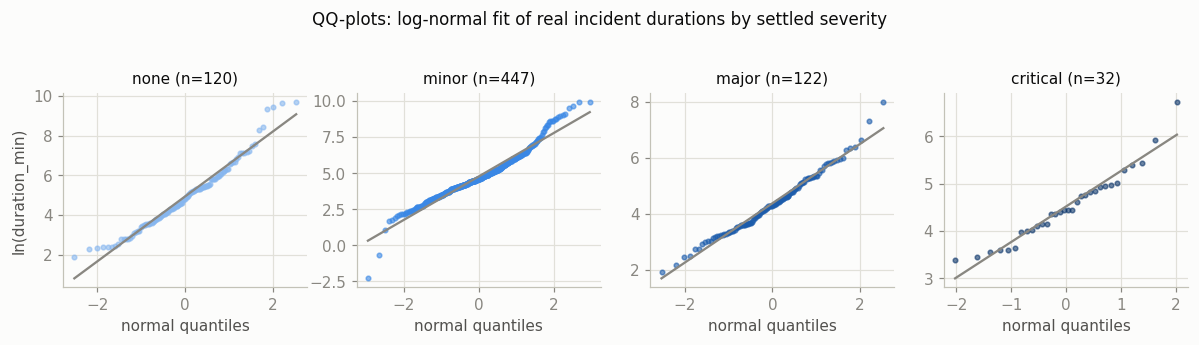

In [4]:
# Assumption test, executed: does a log-normal describe the real durations per severity class?
dur = df[(df["duration_min"] > 0)].dropna(subset=["duration_min"])
fits, rows = {}, []
for sev in sev_order:
    g = dur.loc[dur["impact"] == sev, "duration_min"]
    logs = np.log(g.values)
    mu, sig = logs.mean(), logs.std(ddof=1)
    fits[sev] = (mu, sig)
    sh = stats.shapiro(logs)
    rows.append({"severity": sev, "n": len(g), "log-mean": round(mu, 2),
                 "log-sd": round(sig, 2), "fitted median (min)": round(np.exp(mu), 1),
                 "Shapiro p on ln(dur)": round(sh.pvalue, 4)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nDurations used for fitting: {len(dur)} positive durations "
      f"(pooled across providers; cross-provider DURATION pooling is allowed, "
      f"unlike rate pooling).")

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, sev in zip(axes, sev_order):
    logs = np.log(dur.loc[dur["impact"] == sev, "duration_min"].values)
    (osm, osr), _ = stats.probplot(np.sort(logs), dist="norm")
    ax.plot(osm, osr, "o", ms=3, color=SEV_RAMP[sev], alpha=0.6)
    lo, hi = osm.min(), osm.max()
    mu, sig = fits[sev]
    ax.plot([lo, hi], [mu + sig * lo, mu + sig * hi], color=MUTED, linewidth=1.5)
    ax.set_title(f"{sev} (n={ (dur['impact'] == sev).sum() })", fontsize=10)
    ax.set_xlabel("normal quantiles")
axes[0].set_ylabel("ln(duration_min)")
fig.suptitle("QQ-plots: log-normal fit of real incident durations by settled severity",
             y=1.03, fontsize=11)
fig.tight_layout()
plt.show()

I'll say the fit verdict honestly, because it affects how much to trust the tournament:
log-normality is *not rejected* for critical (n=32, p≈0.16) and major (n=122, p≈0.17), but it
is rejected for minor (n=447, p<0.001) and for none (n=120, p≈0.003). That is the mixture
character of pooling 18 providers' reporting habits into a single class, and the QQ-plots show
it directly. Two consequences follow. I re-run the tournament with non-parametric empirical
resampling (bootstrap from the actual per-class durations) as a robustness row in the
sensitivity table. And I want to flag the perverse ordering of the fitted medians on its own
terms: critical incidents have the *shortest* fitted median duration (~92 min), and `none` the
longest (~141 min). Providers close what hurts them fastest; low-severity incidents linger.
That asymmetry alone is why a policy that ties an engineer to an incident until closure is
dangerous.

Tournament design, declared before running it: replay the peak week **1,000×**. Real arrival
times and severities stay fixed; per-incident $R_i$ is resampled from the fitted per-severity
log-normal and $M_i$ from the declared mitigation model. Within a replicate all policies see
identical draws (common random numbers, so differences are pure policy effects).
`rng = np.random.default_rng(20240401)`. A "win" requires strictly lower damage; exact ties
are reported as ties.

In [5]:
ALPHA = 0.3
MIT_MED = {"none": 20.0, "minor": 30.0, "major": 60.0, "critical": 90.0}
MIT_SIG = 0.6
N_ENG = 2
TOL = 1e-9

def simulate(arr, sev, R, M, policy, weights=W_DEFAULT, alpha=ALPHA,
             mitmed=MIT_MED, n_eng=N_ENG):
    """Discrete-event replay (heapq, minute resolution). Returns total damage
    = integral of the severity-weighted open-incident curve (mitigated incidents at alpha*w)."""
    n = len(arr)
    close = arr + R                      # provider close times — policy-independent
    mit_mean = {s: m * np.exp(MIT_SIG ** 2 / 2) for s, m in mitmed.items()}

    def key(i):
        if policy == "fifo":
            return (arr[i], i)
        if policy == "sev":
            return (-weights[sev[i]], arr[i], i)
        if policy == "cmu":
            return (-(1 - alpha) * weights[sev[i]] / mit_mean[sev[i]], arr[i], i)
        if policy == "sev_release":
            return (-weights[sev[i]], arr[i], i)
        raise ValueError(policy)

    own = policy in ("fifo", "sev")      # engineer stays until provider closes
    events, seq = [], 0
    for i in range(n):
        heapq.heappush(events, (arr[i], seq, i)); seq += 1   # arrivals; frees pushed later
    queue, free = set(), n_eng
    t_mit = [None] * n
    while events:
        t, _, i = heapq.heappop(events)
        if i >= 0:
            queue.add(i)
        else:
            free += 1
        while free > 0 and queue:
            live = [j for j in queue if close[j] > t]
            for j in queue - set(live):
                queue.discard(j)                      # provider already closed it
            if not live:
                break
            j = min(live, key=key)
            queue.discard(j); free -= 1
            tm = t + M[j]
            if tm < close[j]:
                t_mit[j] = tm
            release = close[j] if own else min(tm, close[j])
            heapq.heappush(events, (release, seq, -1)); seq += 1
    dmg = 0.0
    for i in range(n):
        w = weights[sev[i]]
        if t_mit[i] is not None:
            dmg += w * (t_mit[i] - arr[i]) + alpha * w * (close[i] - t_mit[i])
        else:
            dmg += w * (close[i] - arr[i])
    return dmg

arr = ((week["created_at"] - week_start).dt.total_seconds() / 60.0).values
sev = list(week["impact"])

N_REP = 1000
policies = ["fifo", "sev", "cmu", "sev_release"]
rng = np.random.default_rng(20240401)
res = {p: np.zeros(N_REP) for p in policies}
for rep in range(N_REP):
    R = np.array([np.exp(rng.normal(*fits[s])) for s in sev])
    M = np.array([MIT_MED[s] * np.exp(rng.normal(0, MIT_SIG)) for s in sev])
    for p in policies:
        res[p][rep] = simulate(arr, sev, R, M, p)
res = pd.DataFrame(res)

print("Mean damage per replicate (severity-weighted open-incident HOURS):")
for p in policies:
    print(f"  {p:12s} mean {res[p].mean()/60:7.1f}   median {res[p].median()/60:7.1f}")

cmu_strict = (res["cmu"] < res[["fifo", "sev"]].min(axis=1) - TOL).mean()
cmu_loses  = (res["cmu"] > res[["fifo", "sev"]].min(axis=1) + TOL).mean()
three_tie  = ((res[["fifo", "sev", "cmu"]].max(axis=1)
               - res[["fifo", "sev", "cmu"]].min(axis=1)) < TOL).mean()
fifo_eq_sev = ((res["fifo"] - res["sev"]).abs() < TOL).mean()
sev_beats_fifo = (res["sev"] < res["fifo"] - TOL).mean()
fifo_beats_sev = (res["fifo"] < res["sev"] - TOL).mean()

m_cf = (1 - res["cmu"] / res["fifo"]) * 100
m_cs = (1 - res["cmu"] / res["sev"]) * 100
m_sf = (1 - res["sev"] / res["fifo"]) * 100
print(f"\ncμ strictly best: {cmu_strict:.1%} of replicates | "
      f"strictly beaten: {cmu_loses:.1%} | exact three-way tie: {three_tie:.1%}")
print(f"FIFO and severity-first produce IDENTICAL damage in {fifo_eq_sev:.1%} of replicates")
print(f"  severity-first strictly beats FIFO: {sev_beats_fifo:.1%} "
      f"(mean margin {m_sf.mean():.2f}%); FIFO strictly beats severity-first: "
      f"{fifo_beats_sev:.1%}")
print(f"cμ margin vs FIFO: mean {m_cf.mean():.1f}%, median {m_cf.median():.1f}%, "
      f"IQR [{m_cf.quantile(.25):.1f}%, {m_cf.quantile(.75):.1f}%], "
      f"p95 {m_cf.quantile(.95):.1f}%")
print(f"cμ margin vs severity-first: mean {m_cs.mean():.1f}%")
print(f"Decomposition: cμ identical to severity-first+release in every replicate: "
      f"{np.allclose(res['cmu'], res['sev_release'])}")

Mean damage per replicate (severity-weighted open-incident HOURS):


  fifo         mean   127.8   median   121.7
  sev          mean   127.5   median   121.6
  cmu          mean   120.2   median   116.2
  sev_release  mean   120.2   median   116.2



cμ strictly best: 94.7% of replicates | strictly beaten: 0.0% | exact three-way tie: 5.3%
FIFO and severity-first produce IDENTICAL damage in 79.0% of replicates
  severity-first strictly beats FIFO: 12.6% (mean margin 0.23%); FIFO strictly beats severity-first: 8.4%
cμ margin vs FIFO: mean 5.3%, median 3.7%, IQR [1.3%, 7.7%], p95 16.4%
cμ margin vs severity-first: mean 5.1%
Decomposition: cμ identical to severity-first+release in every replicate: True


In [6]:
# How much of the damage is controllable at all? Lower bound = infinite engineers
# (every mitigation starts the instant the incident arrives).
rng = np.random.default_rng(20240401)
ctrl = []
for rep in range(300):
    R = np.array([np.exp(rng.normal(*fits[s])) for s in sev])
    M = np.array([MIT_MED[s] * np.exp(rng.normal(0, MIT_SIG)) for s in sev])
    lb = sum(W_DEFAULT[s] * min(m, r) + ALPHA * W_DEFAULT[s] * max(0.0, r - m)
             for s, r, m in zip(sev, R, M))
    ctrl.append((simulate(arr, sev, R, M, "fifo") - lb) / simulate(arr, sev, R, M, "fifo"))
print(f"Controllable share of FIFO damage (mean over 300 replicates): "
      f"{np.mean(ctrl)*100:.1f}%")
print("Everything else is provider resolution time we cannot influence.")

Controllable share of FIFO damage (mean over 300 replicates): 5.1%
Everything else is provider resolution time we cannot influence.


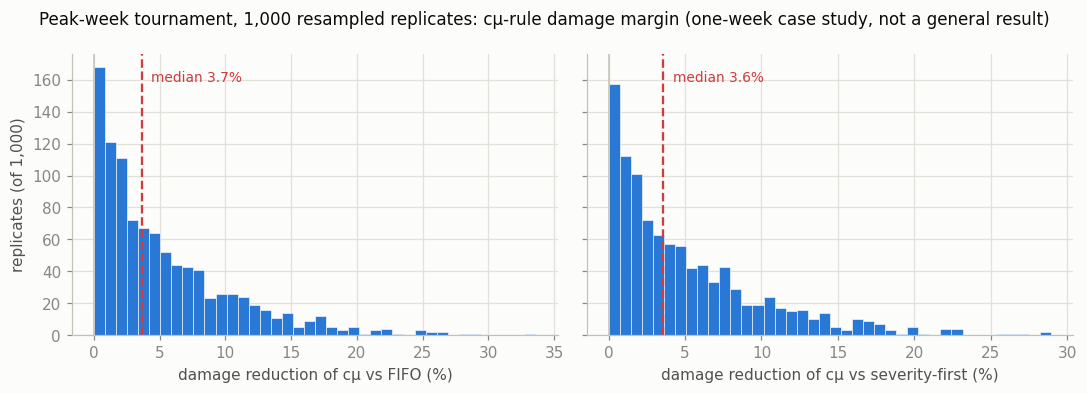

In [7]:
# Figure 2 — tournament margin distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, margins, other in [(axes[0], m_cf, "FIFO"), (axes[1], m_cs, "severity-first")]:
    ax.hist(margins, bins=40, color=POLICY_COLORS["FIFO"], edgecolor=SURFACE, linewidth=0.4)
    ax.axvline(0, color=AXIS, linewidth=1)
    ax.axvline(margins.median(), color=CRITICAL_RED, linewidth=1.5, linestyle="--")
    ax.annotate(f"median {margins.median():.1f}%", xy=(margins.median(), 0.9),
                xycoords=("data", "axes fraction"), color=CRITICAL_RED, fontsize=9,
                xytext=(6, 0), textcoords="offset points")
    ax.set_xlabel(f"damage reduction of cμ vs {other} (%)")
axes[0].set_ylabel("replicates (of 1,000)")
fig.suptitle("Peak-week tournament, 1,000 resampled replicates: cμ-rule damage margin "
             "(one-week case study, not a general result)", fontsize=11)
fig.tight_layout()
plt.show()

Over 1,000 resampled replicates of the reconstructed real peak week, the cμ-rule is strictly
best 94.7% of the time and is never strictly beaten; the remaining 5.3% are exact three-way
ties, replicates where the queue never forms and discipline stops mattering. Mean damage:
cμ ≈ 120 vs FIFO ≈ 128 weighted open-incident hours. The margin is real but modest, and
right-skewed: median 3.7%, mean 5.3% vs FIFO (IQR 1.3–7.7%, 95th percentile 16.4%, the margin
growing when a long incident lands on an already-busy day).

FIFO vs severity-first, on the other hand, is a statistical tie: identical damage in 79% of
replicates, and a mean margin of only ~0.2% when they differ. This is not a simulation
artifact; it is a statement about how thin this particular queue is: with 28 arrivals over
7 days and 2 engineers, a second waiting incident is rarely there to compete for the front of
the line, so *ordering* has almost nothing to bite on. Given a higher arrival rate, fewer
engineers, longer ownership times, or a mixed backlog when a critical lands, I'd expect the two
to separate, and that is exactly the stress test below.

The decomposition is the actual finding here. Severity-first + release is *identical to cμ in
every replicate* (under these mitigation-effort assumptions, cμ ordering happens to coincide
with severity ordering; the sensitivity section shows when it would not). Which means the
entire cμ advantage traces to one lever, the release rule (never staffing μ≈0 monitoring), and
none of it to cleverer ordering.

Put these two findings together and the scale of the opportunity comes into focus: only ≈5% of
total damage is controllable at all, the rest being provider resolution time nobody on this
team can touch. The cμ-rule captures essentially all of that 5%; the ownership policies spend
most of it babysitting incidents they cannot resolve.

The prescriptive reading, then: in a provider-blocked overload, the leverage is not *which*
ticket you pick first. It is refusing to let engineers wait on a provider at all.

Sensitivity (300 replicates each, seed 20240401):
                              cμ strict win %  exact tie %  cμ loses %  mean margin %
default weights 0.5/1/3/9                92.3          7.7         0.0            4.9
flat weights 1/1/1/1                     92.3          7.7         0.0            8.1
steep weights 0.5/1/5/25                 92.3          7.7         0.0            3.3
mitigation effort ×2                     87.7         12.3         0.0            3.4
mitigation effort ×0.5                   93.3          6.7         0.0            6.6
critical mitigation = 8 h                92.3          7.7         0.0            3.9
empirical duration bootstrap             92.3          7.7         0.0            4.9


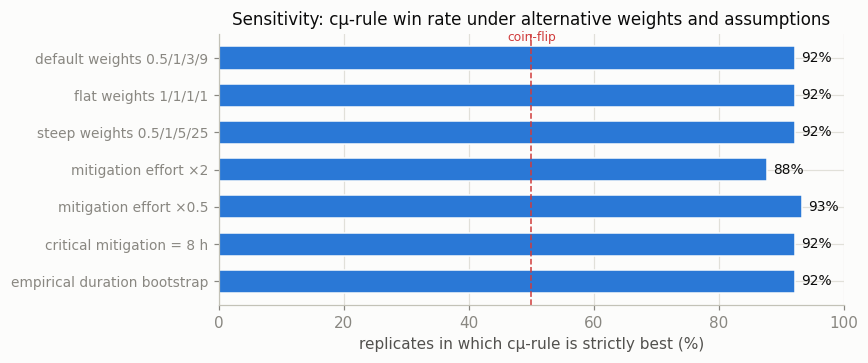

In [8]:
# Sensitivity: severity weights (mandated), the invented mitigation model, and the
# distributional assumption (empirical bootstrap instead of log-normal).
emp = {s: dur.loc[dur["impact"] == s, "duration_min"].values for s in sev_order}

def tournament(weights=W_DEFAULT, mitmed=MIT_MED, empirical=False, n_rep=300):
    rng = np.random.default_rng(20240401)
    out = {p: np.zeros(n_rep) for p in ["fifo", "sev", "cmu"]}
    for rep in range(n_rep):
        if empirical:
            R = np.array([rng.choice(emp[s]) for s in sev])
        else:
            R = np.array([np.exp(rng.normal(*fits[s])) for s in sev])
        M = np.array([mitmed[s] * np.exp(rng.normal(0, MIT_SIG)) for s in sev])
        for p in out:
            out[p][rep] = simulate(arr, sev, R, M, p, weights=weights, mitmed=mitmed)
    o = pd.DataFrame(out)
    return {
        "cμ strict win %": 100 * (o["cmu"] < o[["fifo", "sev"]].min(axis=1) - TOL).mean(),
        "exact tie %": 100 * ((o.max(axis=1) - o.min(axis=1)) < TOL).mean(),
        "cμ loses %": 100 * (o["cmu"] > o[["fifo", "sev"]].min(axis=1) + TOL).mean(),
        "mean margin %": 100 * (1 - o["cmu"] / o[["fifo", "sev"]].min(axis=1)).mean(),
    }

scenarios = {
    "default weights 0.5/1/3/9": dict(),
    "flat weights 1/1/1/1": dict(weights={s: 1.0 for s in sev_order}),
    "steep weights 0.5/1/5/25": dict(weights={"none": .5, "minor": 1, "major": 5, "critical": 25}),
    "mitigation effort ×2": dict(mitmed={k: 2 * v for k, v in MIT_MED.items()}),
    "mitigation effort ×0.5": dict(mitmed={k: .5 * v for k, v in MIT_MED.items()}),
    "critical mitigation = 8 h": dict(mitmed={**MIT_MED, "critical": 480.0}),
    "empirical duration bootstrap": dict(empirical=True),
}
sens = pd.DataFrame({name: tournament(**kw) for name, kw in scenarios.items()}).T.round(1)
print("Sensitivity (300 replicates each, seed 20240401):")
print(sens.to_string())

fig, ax = plt.subplots(figsize=(8, 3.4))
y = np.arange(len(sens))[::-1]
ax.barh(y, sens["cμ strict win %"], height=0.62, color=POLICY_COLORS["FIFO"],
        edgecolor=SURFACE)
for yi, v in zip(y, sens["cμ strict win %"]):
    ax.annotate(f"{v:.0f}%", xy=(v, yi), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
ax.axvline(50, color=CRITICAL_RED, linewidth=1, linestyle="--")
ax.annotate("coin-flip", xy=(50, y.max() + .45), color=CRITICAL_RED, fontsize=8, ha="center")
ax.set_yticks(y); ax.set_yticklabels(sens.index, fontsize=9)
ax.set_xlim(0, 100); ax.set_xlabel("replicates in which cμ-rule is strictly best (%)")
ax.set_title("Sensitivity: cμ-rule win rate under alternative weights and assumptions")
fig.tight_layout()
plt.show()

Across every scenario I probed, the ranking holds: the cμ win rate stays at 88–93%, and cμ
never becomes strictly worse in a single replicate of any scenario. What the knobs move is the
*size* of the win, not the winner. Flat weights widen the margin (≈8%: once everything is
weighted equally, raw mitigation throughput is all that matters), while steep weights and
doubled mitigation effort narrow it to 3.3–3.4%. The empirical bootstrap row confirms the
log-normal misfit for minor/none isn't secretly driving the result. The scenario I find most
interesting conceptually is "critical mitigation = 8 h": there the cμ *ordering* genuinely
diverges from severity ordering (a critical's w/E[M] index drops below a minor's, so cμ
schedules the quick minors before the marathon critical war-room), and the win rate barely
moves, which is the strongest evidence I have that the release rule, not the ordering, is doing
the work at this load.

## Hypothetical stress test — THIS SCENARIO DID NOT OCCUR IN THE DATA

Everything in this section is synthetic by construction and labeled as such. In the real peak
week there was never more than **1** critical open at a time. Here we ask where the policies
*would* diverge sharply: **4 critical incidents arriving within 30 minutes into a backlog of
8 minor incidents**, 2 engineers, same damage model, same resampling machinery (durations drawn
from the per-severity fits), 1,000 replicates, seed 20240401. The backlog is the point: ordering
only matters when a queue exists at the moment the criticals land.

FIFO             mean   94.1  median   87.5 weighted open-incident hours
Severity-first   mean   90.9  median   85.3 weighted open-incident hours
cμ-rule          mean   76.0  median   72.4 weighted open-incident hours

cμ strictly best: 99.5%
severity-first strictly beats FIFO: 42.0% (mean margin 2.8%); FIFO strictly beats severity-first: 29.7%
cμ margin vs FIFO: mean 17.4%  |  vs severity-first: mean 15.1%


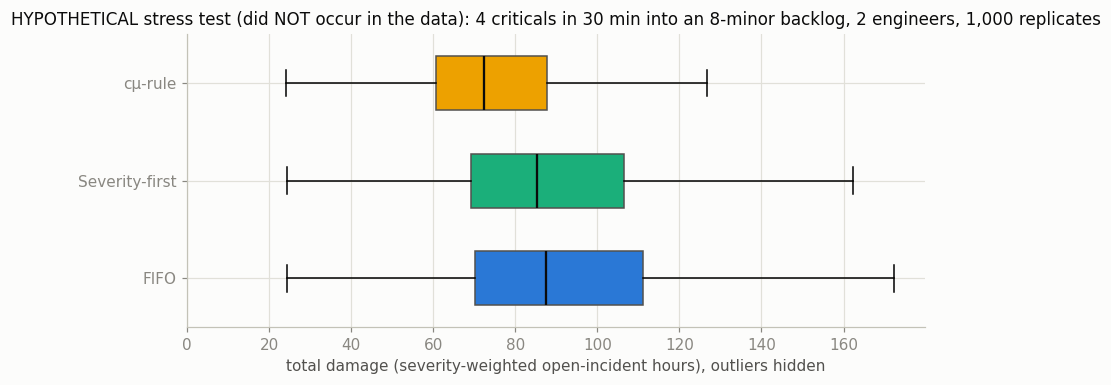

In [9]:
s_arr = np.array([0., 10., 20., 30., 40., 50., 60., 70.,   # 8 minors, a backlog
                  90., 100., 110., 120.])                   # then 4 criticals in 30 min
s_sev = ["minor"] * 8 + ["critical"] * 4

rng = np.random.default_rng(20240401)
sres = {p: np.zeros(1000) for p in ["fifo", "sev", "cmu"]}
for rep in range(1000):
    R = np.array([np.exp(rng.normal(*fits[s])) for s in s_sev])
    M = np.array([MIT_MED[s] * np.exp(rng.normal(0, MIT_SIG)) for s in s_sev])
    for p in sres:
        sres[p][rep] = simulate(s_arr, s_sev, R, M, p)
sres = pd.DataFrame(sres)

labels = {"fifo": "FIFO", "sev": "Severity-first", "cmu": "cμ-rule"}
for p in sres:
    print(f"{labels[p]:16s} mean {sres[p].mean()/60:6.1f}  median {sres[p].median()/60:6.1f} "
          f"weighted open-incident hours")
print(f"\ncμ strictly best: "
      f"{(sres['cmu'] < sres[['fifo','sev']].min(axis=1) - TOL).mean():.1%}")
print(f"severity-first strictly beats FIFO: {(sres['sev'] < sres['fifo'] - TOL).mean():.1%} "
      f"(mean margin {((1 - sres['sev']/sres['fifo'])*100).mean():.1f}%); "
      f"FIFO strictly beats severity-first: {(sres['fifo'] < sres['sev'] - TOL).mean():.1%}")
print(f"cμ margin vs FIFO: mean {((1 - sres['cmu']/sres['fifo'])*100).mean():.1f}%  |  "
      f"vs severity-first: mean {((1 - sres['cmu']/sres['sev'])*100).mean():.1f}%")

fig, ax = plt.subplots(figsize=(8, 3.6))
data = [sres[p] / 60 for p in ["fifo", "sev", "cmu"]]
bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.55, showfliers=False,
                medianprops=dict(color=INK, linewidth=1.5))
for patch, p in zip(bp["boxes"], ["fifo", "sev", "cmu"]):
    patch.set_facecolor(POLICY_COLORS[labels[p]]); patch.set_edgecolor(INK2)
ax.set_yticks([1, 2, 3]); ax.set_yticklabels([labels[p] for p in ["fifo", "sev", "cmu"]])
ax.set_xlabel("total damage (severity-weighted open-incident hours), outliers hidden")
ax.set_xlim(0, None)
ax.set_title("HYPOTHETICAL stress test (did NOT occur in the data): 4 criticals in 30 min "
             "into an 8-minor backlog, 2 engineers, 1,000 replicates")
fig.tight_layout()
plt.show()

**Stress-test reading.** Under a load that actually saturates 2 engineers, the policies stop
being interchangeable: the cμ-rule is strictly best in ~99% of replicates with a mean margin of
~17% vs FIFO (~15% vs severity-first), and severity-first now separates from FIFO (it strictly
wins 42% of replicates against FIFO's 30%, with 28% exact draws: jumping weight-9 criticals
ahead pays on average (+2.8%), but the draw-to-draw noise of which incidents happen to run
long keeps FIFO competitive in a substantial minority). Two lessons transfer to the
runbook: (1) the ordering axis only matters when a backlog exists, and (2) the ownership
convention is most expensive exactly when you can least afford it, because engineers are welded
to minors while criticals burn at weight 9.

Daily severity-weighted open-incident minutes over the 42-day common window:
  median 1539, p95 3643, max 8850 on 2026-05-08 (2.4x the trigger)


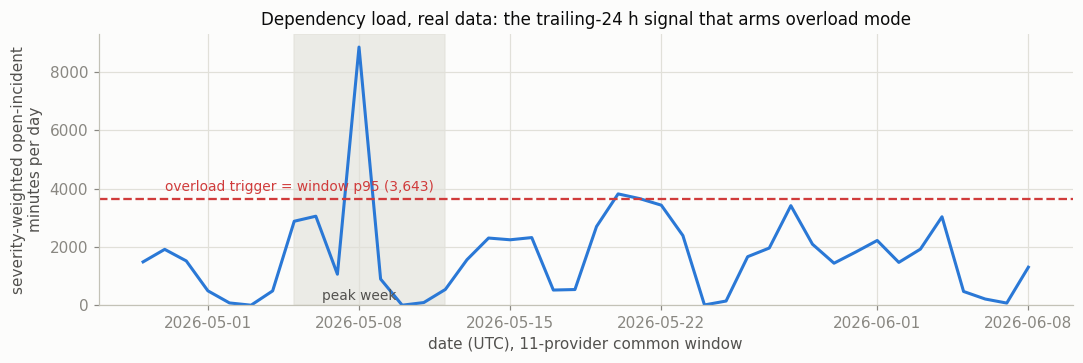

In [10]:
# Overload trigger calibration (NB01-style burn framing on the dependency-load signal):
# daily severity-weighted open-incident minutes across the whole common window, real data.
days = pd.date_range(cw_start.floor("D"), cw_end.ceil("D"), freq="D", tz="UTC")
load = []
for d in days[:-1]:
    d2, tot = d + pd.Timedelta("1D"), 0.0
    for _, r in cw.dropna(subset=["resolved_at"]).iterrows():
        s_, e_ = max(r["created_at"], d), min(r["resolved_at"], d2)
        if e_ > s_:
            tot += W_DEFAULT[r["impact"]] * (e_ - s_).total_seconds() / 60
    load.append(tot)
load = pd.Series(load, index=days[:-1])
trigger = load.quantile(0.95)
print(f"Daily severity-weighted open-incident minutes over the {cw_days:.0f}-day common "
      f"window:\n  median {load.median():.0f}, p95 {trigger:.0f}, "
      f"max {load.max():.0f} on {load.idxmax():%Y-%m-%d} "
      f"({load.max()/trigger:.1f}x the trigger)")

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(load.index, load.values, color=POLICY_COLORS["FIFO"], linewidth=2)
ax.axhline(trigger, color=CRITICAL_RED, linestyle="--", linewidth=1.5)
ax.annotate(f"overload trigger = window p95 ({trigger:,.0f})", xy=(load.index[1], trigger),
            xytext=(0, 5), textcoords="offset points", color=CRITICAL_RED, fontsize=9)
ax.axvspan(week_start, week_end, color=GRID, alpha=0.6, zorder=0)
ax.annotate("peak week", xy=(week_start + pd.Timedelta("3D"), ax.get_ylim()[1]*0.02),
            color=INK2, fontsize=9, ha="center")
ax.set_ylabel("severity-weighted open-incident\nminutes per day")
ax.set_xlabel("date (UTC), 11-provider common window")
ax.set_ylim(0, None)
ax.set_title("Dependency load, real data: the trailing-24 h signal that arms overload mode")
fig.tight_layout()
plt.show()

## 6. What I would actually change — the overload runbook

NB01 frames provider misbehavior as error-budget burn rate; the same idea applied to workload
gives me the trigger below. A scope reminder I want attached to every number here: they come
from one 41.6-day common window and one simulated model. I treat them as a starting
calibration, not a verdict, to be re-fit as more data accumulates.

**Trigger — entering overload mode.** Arm overload mode when the trailing-24 h
severity-weighted dependency-open time exceeds the common-window p95 (**≈ 3,640 weighted
minutes**, vs a median day of ≈ 1,540). The real peak week would have fired it: 2026-05-08 hit
≈ 8,850, about **2.4× the trigger**. Exit when the signal stays below the median for 24 h.

**Roles while in overload mode (2 engineers on call):**

- **Engineer A — mitigation queue.** Works *mitigation tasks*, not incidents, in cμ order
  (with our declared parameters that ordering coincides with severity order; if a mitigation
  is known to be a marathon, its priority index drops — that is the rule working, not a bug).
  Releases each incident the moment its mitigation lands.
- **Engineer B — communication.** Owns the aggregate: our own status page, proactive customer
  comms, batching updates across all open incidents on a fixed cadence (e.g. every 30 min).
  Communication is mitigation with μ > 0 — it earns its damage reduction.
- **Degraded-mode actions:** pause non-emergency deploys, widen internal SLO alerting to
  acknowledge the dependency incident, pre-write the postmortem timeline as events happen.

The rule I would actually put in the runbook: nobody's job is to watch a provider's status
page. Watching has service rate μ ≈ 0 and damage reduction 0 (its cμ index is 0 by
construction), and both the real-week replay (the entire ~5% win traced to the release rule)
and the stress test (~17%) put a price on the habit anyway. Subscribe to the provider's
webhook or RSS feed, let the *provider's* resolution event re-enter the queue as a 5-minute
closeout task, and spend engineer-minutes only where μ > 0.

## 7. Where I would not follow this data

Here is where I would stop trusting this notebook past its evidence:

- **This is one week, one panel, one model.** A 28-incident week replayed 1,000× quantifies
  *simulation* uncertainty, not *world* uncertainty; the next overload week will have a
  different mix. "cμ wins 94.7% of replicates of this week" is not "cμ is optimal in general".
- **The mitigation model is invented.** $M_i$, α = 0.3, and the severity weights are
  declared assumptions, sensitivity-checked but not measured. The direction of the conclusion
  (never staff μ≈0 waiting) survives every probe we made; the margins (3–17%) should not be
  quoted without their assumptions.
- **Severities are settled, not minute-0**, so a real-time triager would sometimes misclassify
  arrivals, degrading severity-based policies relative to this replay; impact conventions also
  differ across the 18 providers.
- **Declared incidents only.** Status pages under-report; the true dependency load is higher
  than what any figure here shows.
- The simulation ignores preemption, handoffs, fatigue, context-switching costs, and the
  possibility that "monitoring" occasionally *is* productive (e.g. spotting that a provider's
  fix regressed). Those costs cut against frequent re-prioritization, which is a reason to run
  cμ over *mitigation tasks* (which are short) rather than preempting mid-task.
- Nothing here says anything about **how many** engineers to staff. That is NB03's question,
  and its answer is to plan for three, with a defensible range of two to four. This notebook
  deliberately runs the tournament at c = 2 anyway, and not by oversight: triage policy has the
  most leverage exactly on the day you are staffed below the recommendation, not on the day you
  have the recommended headcount and everything is comfortable. Two is the floor of NB03's own
  range, and it is precisely where the ownership habit is most expensive and the cμ-rule's
  advantage is easiest to see; the interesting question was never how three engineers would
  fare, but what a team does when it only has two.